In [1]:
import pandas as pd
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from data_loader import NIH8Dataset, data_transforms
from utils import get_train_val_split, calculate_class_weights
from torch.utils.data.dataloader import default_collate

1. Loading CSV and Splitting by Patient...
Split complete: 89826 train images, 22294 val images.

2. Initializing Dataset (Subset of 100 images)...
Indexing NIH folders...
Files found in path_map: 112120

3. Checking Class Weights...
Class weights calculated for 15 classes.

4. Testing the DataLoader...
Batch Image Shape: torch.Size([4, 1, 256, 256])


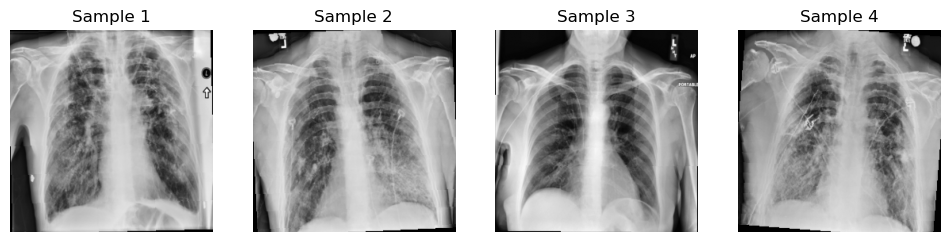


Sanity Check Complete!


In [2]:
def safe_collate(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0: return None
    return default_collate(batch)

# --- CONFIG ---
CSV_PATH = r"C:\Users\danny\OneDrive\Documents\UCSD\DSC288R\Data_Entry_2017.csv" 
# Just the parent folder now
IMAGE_FOLDERS = [r"C:\Users\danny\OneDrive\Documents\UCSD\DSC288R\images"] 

print("1. Loading CSV and Splitting by Patient...")
df = pd.read_csv(CSV_PATH)
train_df, val_df = get_train_val_split(df, train_size=0.8)

print("\n2. Initializing Dataset (Subset of 100 images)...")
test_ds = NIH8Dataset(train_df, IMAGE_FOLDERS, subset_size=100, transform=data_transforms)

# CHECKPOINT: Print this to verify the walk worked!
print(f"Files found in path_map: {len(test_ds.path_map)}") 

print(f"\n3. Checking Class Weights...")
weights, weight_dict = calculate_class_weights(test_ds)
print(f"Class weights calculated for {len(weight_dict)} classes.")

print("\n4. Testing the DataLoader...")
# 2. ADD THIS: use collate_fn=safe_collate
test_loader = DataLoader(test_ds, batch_size=4, shuffle=True, collate_fn=safe_collate)

# 3. FIX THIS: Handle the possibility of a None batch
batch = next(iter(test_loader))
if batch is None:
    print("Error: Entire batch was empty. Check image paths!")
else:
    images = batch['image']
    labels = batch['labels']
    print(f"Batch Image Shape: {images.shape}")
    
    # Visual Confirmation
    plt.figure(figsize=(12, 4))
    for i in range(min(4, len(images))):
        plt.subplot(1, 4, i+1)
        img = images[i].squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(f"Sample {i+1}")
    plt.show()

print("\nSanity Check Complete!")

In [3]:
# Check the first few paths the dataset generated
print(f"Total files indexed in path_map: {len(test_ds.path_map)}")
sample_img = test_ds.df.iloc[0]['Image Index']
print(f"Looking for: {sample_img}")
print(f"Path found in map: {test_ds.path_map.get(sample_img)}")

Total files indexed in path_map: 112120
Looking for: 00000351_000.png
Path found in map: C:\Users\danny\OneDrive\Documents\UCSD\DSC288R\images\images_001\images\00000351_000.png
